# Colombo North Urban & Flood EDA
This notebook performs Exploratory Data Analysis (EDA) on the Colombo North region, focusing on the intersection between building footprints and flood risk zones.

In [1]:
import os
import sys
import json
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import folium
from shapely.geometry import box

# Setup path to include backend source
REPO_ROOT = os.path.abspath("..")
sys.path.append(os.path.join(REPO_ROOT, "backend/src"))

from application.analysis.urban_eda_service import UrbanEdaService

print("Libraries imported and sys.path configured.")

Libraries imported and sys.path configured.


In [2]:
# Constants and Paths
COLOMBO_NORTH_BOUNDS = [79.85, 6.935, 79.89, 6.975] # [minx, miny, maxx, maxy]
TARGET_CRS = "EPSG:32644" # local UTM projection for area analysis

BUILDINGS_PATH = os.path.join(REPO_ROOT, "backend/cache/colombo_north_buildings.geojson")
FLOOD_MAP_PATH_RAW = os.path.join(REPO_ROOT, "data/raw/flood_maps/FL20251128LKA_SHP") # Directory containing shapefiles
NDVI_TIF_PATH = os.path.join(REPO_ROOT, "data/raw/satellite/colombo_north_ndvi.tif")

print(f"Paths defined relative to {REPO_ROOT}")

Paths defined relative to /Users/nadunhettiarachchi/MDSAI/Semester-03/Capstone_project/GeoAI


In [6]:
# Load building and flood datasets
print("Loading building footprints...")
buildings_gdf = gpd.read_file(BUILDINGS_PATH)
print(f"Loaded {len(buildings_gdf)} buildings.")

# Find any .shp file in the flood directory
print("Loading flood map shapefiles...")
shp_files = [f for f in os.listdir(FLOOD_MAP_PATH_RAW) if f.endswith('.shp')]
if shp_files:
    flood_gdf = gpd.read_file(os.path.join(FLOOD_MAP_PATH_RAW, shp_files[0]))
    print(f"Loaded {len(flood_gdf)} flood polygons.")
else:
    print("Warning: No shapefiles found in flood directory.")
    flood_gdf = None

# Inspection: Ensure WGS84 for coordination
print(f"Buildings CRS: {buildings_gdf.crs}")
if flood_gdf is not None:
    print(f"Flood CRS: {flood_gdf.crs}")
    # Reproject if they don't match
    if flood_gdf.crs != buildings_gdf.crs:
        print("Reprojecting flood data to match buildings CRS...")
        flood_gdf = flood_gdf.to_crs(buildings_gdf.crs)

Loading building footprints...
Loaded 34958 buildings.
Loading flood map shapefiles...
Loaded 1 flood polygons.
Buildings CRS: EPSG:4326
Flood CRS: EPSG:4326


In [7]:
# Spatial Analysis Logic: Intersection & Risk Assessment
# Identify buildings at risk - within or intersecting with flood polygons
print("Calculating spatial intersection...")

if flood_gdf is not None:
    # Convert to locally accurate metric CRS for area calculation
    buildings_metric = buildings_gdf.to_crs(TARGET_CRS)
    flood_metric = flood_gdf.to_crs(TARGET_CRS)
    
    # Simple 'within' join or 'intersects' join
    buildings_at_risk = gpd.sjoin(buildings_metric, flood_metric, predicate='intersects')
    
    print(f"Total Buildings analyzed: {len(buildings_gdf)}")
    print(f"Buildings at risk: {len(buildings_at_risk)}")
    print(f"Risk percentage: {(len(buildings_at_risk)/len(buildings_gdf))*100:.2f}%")
else:
    print("Skipping intersection calculation - no flood data loaded.")

Calculating spatial intersection...
Total Buildings analyzed: 34958
Buildings at risk: 0
Risk percentage: 0.00%


Creating static visualization...
Notice: No flood data overlaps with the study area.


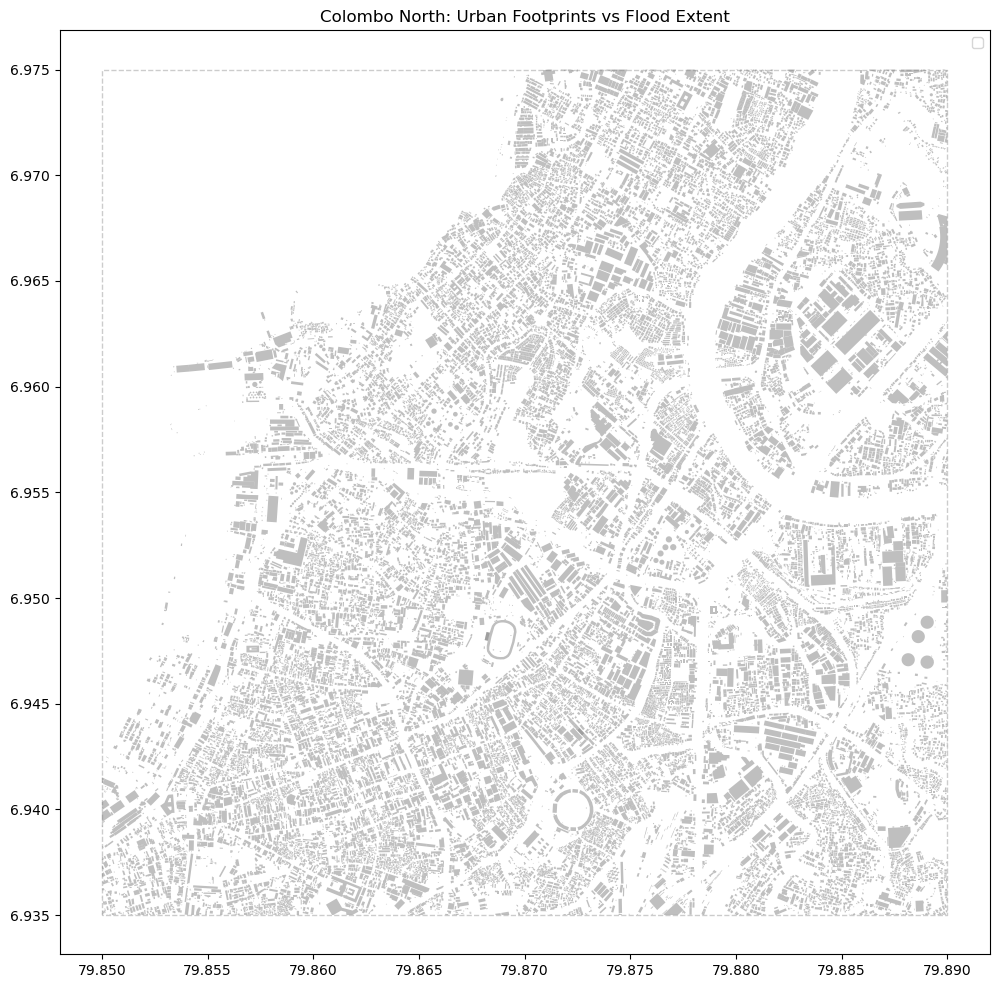

Regional building density: 1788.56 buildings/sqkm


In [8]:
# Visualization: Build a simple map overlay
print("Creating static visualization...")

# Setup plot
fig, ax = plt.subplots(figsize=(12, 12))

# Boundary for alignment
study_area = box(*COLOMBO_NORTH_BOUNDS)
study_area_gdf = gpd.GeoDataFrame(geometry=[study_area], crs="EPSG:4326")

# Plot the study area boundary first to ensure axes have finite extent and valid aspect ratio
study_area_gdf.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linestyle='--', label='Study Area')

# Clip all data to study area
buildings_clipped = gpd.clip(buildings_gdf, study_area_gdf)

if flood_gdf is not None:
    flood_clipped = gpd.clip(flood_gdf, study_area_gdf)
    if not flood_clipped.empty:
        flood_clipped.plot(ax=ax, color='blue', alpha=0.3, label='Flood Zones')
    else:
        print("Notice: No flood data overlaps with the study area.")

# Highlight buildings
if not buildings_clipped.empty:
    buildings_clipped.plot(ax=ax, color='grey', alpha=0.5, markersize=1, label='All Buildings')
else:
    print("Warning: No buildings found within the study area bounds.")

if flood_gdf is not None and not buildings_at_risk.empty:
    # Highlight only risk buildings (re-clip for visual clarity)
    buildings_at_risk_clipped = gpd.clip(buildings_at_risk.to_crs("EPSG:4326"), study_area_gdf)
    if not buildings_at_risk_clipped.empty:
        buildings_at_risk_clipped.plot(ax=ax, color='red', markersize=2, label='Buildings at Risk')

plt.title("Colombo North: Urban Footprints vs Flood Extent")
plt.legend()
plt.axis('equal') # Explicitly set aspect ratio
plt.show()

# Optional: Output some summary stats for reference
if not study_area_gdf.empty:
    area_sqkm = study_area_gdf.to_crs(TARGET_CRS).area.iloc[0] / 1e6
    building_density = len(buildings_clipped) / area_sqkm
    print(f"Regional building density: {building_density:.2f} buildings/sqkm")
else:
    print("Error: Study area is empty, cannot calculate density.")

In [9]:
# Debug: Check the geographical extent of the loaded flood data vs the study area
if flood_gdf is not None:
    print(f"Study Area Bounds: {COLOMBO_NORTH_BOUNDS}")
    print(f"Flood Data Total Bounds: {flood_gdf.total_bounds}")
    
    # Calculate overlap manually
    flood_bounds = flood_gdf.total_bounds
    overlap = not (
        flood_bounds[2] < COLOMBO_NORTH_BOUNDS[0] or 
        flood_bounds[0] > COLOMBO_NORTH_BOUNDS[2] or 
        flood_bounds[3] < COLOMBO_NORTH_BOUNDS[1] or 
        flood_bounds[1] > COLOMBO_NORTH_BOUNDS[3]
    )
    print(f"Is there a bounding box overlap? {overlap}")
    
    if not overlap:
        print("Note: The flood dataset provided appears to be outside the Colombo North study area bounding box.")
else:
    print("Flood data not loaded.")

Study Area Bounds: [79.85, 6.935, 79.89, 6.975]
Flood Data Total Bounds: [80.25593664  6.87842268 81.09067989  7.74993196]
Is there a bounding box overlap? False
Note: The flood dataset provided appears to be outside the Colombo North study area bounding box.
